In [2]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

# Đọc dữ liệu
df = pd.read_csv('../media_all_channels.csv')

# Thống kê cho các biến số (Quantitative)
print("Thống kê biến định lượng:")
print(df[['cost', 'impressions', 'revenue']].describe())

# Thống kê cho các biến chữ (Categorical)
print("\nThống kê biến định tính:")
print(df[['channel', 'campaign']].describe())

Thống kê biến định lượng:
               cost    impressions        revenue
count   7644.000000    7644.000000    7644.000000
mean   20201.992149   51521.165097   85383.225014
std    13331.279590   27953.439184   56927.959235
min      935.885399    7741.000000    5910.066439
25%     9298.726347   29370.750000   42765.878556
50%    18433.986965   44080.500000   70341.939321
75%    27735.240525   67556.000000  113293.147966
max    96648.349664  181730.000000  402881.492549

Thống kê biến định tính:
         channel      campaign
count       7644          7644
unique         6             7
top     Facebook  Best Sellers
freq        1274          1092


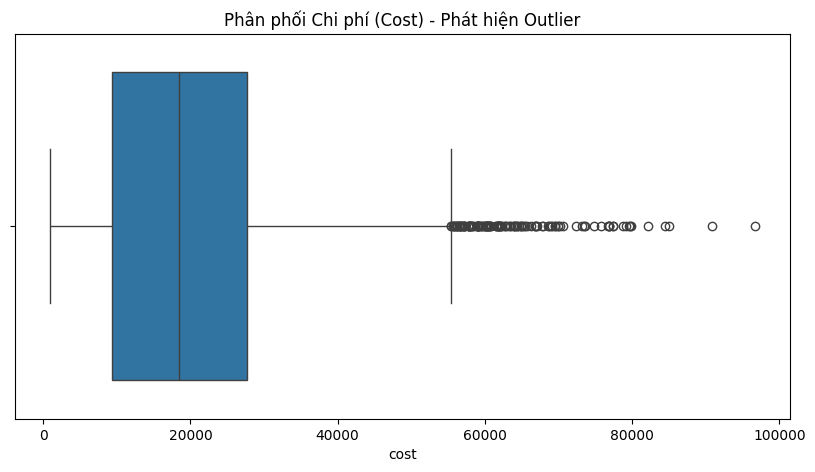

Ngưỡng Outlier: Chi phí > 55390.01
Số lượng dòng Outlier: 128


In [4]:
# 1. Trực quan hóa bằng Boxplot (Biểu đồ hộp râu)
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['cost'])
plt.title('Phân phối Chi phí (Cost) - Phát hiện Outlier')
plt.show()

# 2. Tính toán bằng Toán học (Quy tắc IQR)
Q1 = df['cost'].quantile(0.25) # Tứ phân vị thứ 1 (Mốc 25%)
Q3 = df['cost'].quantile(0.75) # Tứ phân vị thứ 3 (Mốc 75%)
IQR = Q3 - Q1                  # Khoảng tứ phân vị

# Giới hạn trên và dưới
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Lọc ra các dòng là Outlier
outliers = df[(df['cost'] < lower_bound) | (df['cost'] > upper_bound)]
print(f"Ngưỡng Outlier: Chi phí > {upper_bound:.2f}")
print(f"Số lượng dòng Outlier: {len(outliers)}")

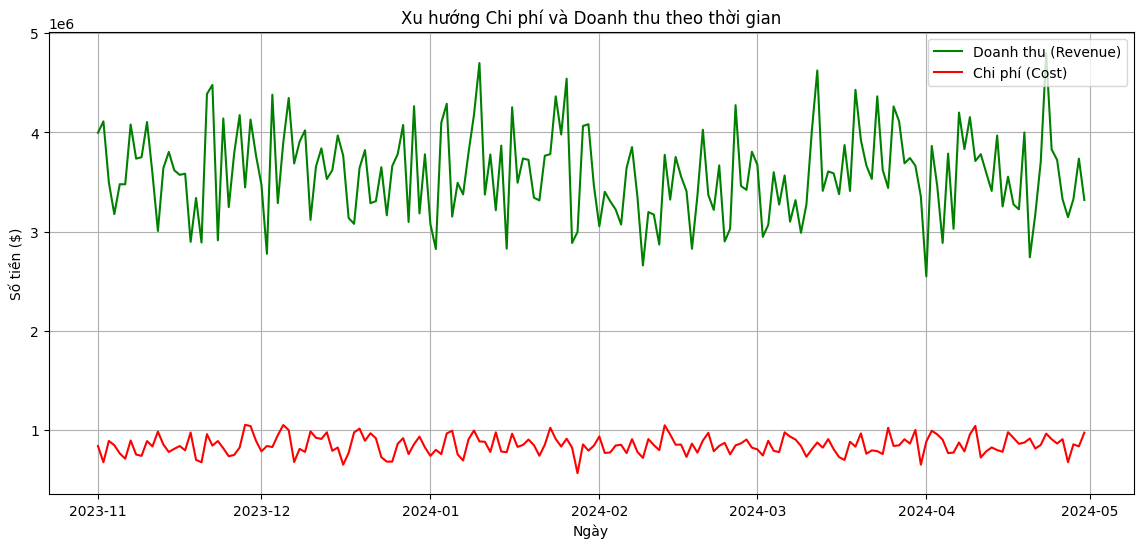

In [5]:
# Chuyển cột date về định dạng thời gian chuẩn
df['date'] = pd.to_datetime(df['date'])

# 1. Tính tổng Doanh thu và Chi phí theo ngày
daily_trend = df.groupby('date')[['cost', 'revenue']].sum()

# Vẽ biểu đồ Line Chart
plt.figure(figsize=(14, 6))
plt.plot(daily_trend.index, daily_trend['revenue'], label='Doanh thu (Revenue)', color='green')
plt.plot(daily_trend.index, daily_trend['cost'], label='Chi phí (Cost)', color='red')

plt.title('Xu hướng Chi phí và Doanh thu theo thời gian')
plt.xlabel('Ngày')
plt.ylabel('Số tiền ($)')
plt.legend()
plt.grid(True)
plt.show()

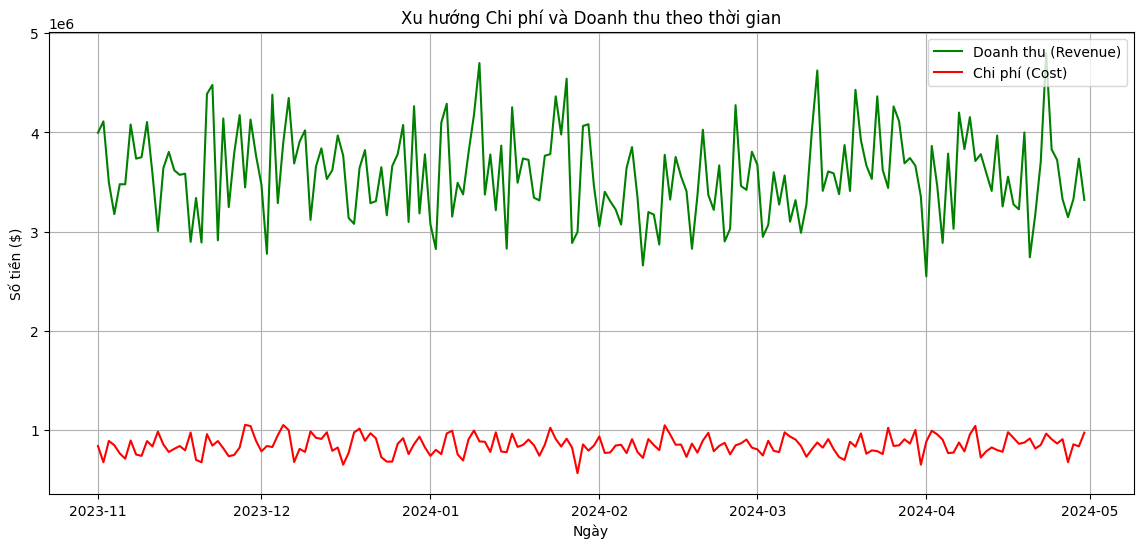

In [6]:
# Chuyển cột date về định dạng thời gian chuẩn
df['date'] = pd.to_datetime(df['date'])

# 1. Tính tổng Doanh thu và Chi phí theo ngày
daily_trend = df.groupby('date')[['cost', 'revenue']].sum()

# Vẽ biểu đồ Line Chart
plt.figure(figsize=(14, 6))
plt.plot(daily_trend.index, daily_trend['revenue'], label='Doanh thu (Revenue)', color='green')
plt.plot(daily_trend.index, daily_trend['cost'], label='Chi phí (Cost)', color='red')

plt.title('Xu hướng Chi phí và Doanh thu theo thời gian')
plt.xlabel('Ngày')
plt.ylabel('Số tiền ($)')
plt.legend()
plt.grid(True)
plt.show()